In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [3]:
this_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/muon_template_northern"

In [23]:
templates = {
    "globalfit" : "/data/ana/Diffuse/GlobalFit/NNMFit/templates/Tracks_CorsikaMuon_Fullrange_drop_5lowEbins.pickle",
    "emre_dnn" : "/data/user/eyildizci/NNMFit_combined_fit_for_pev/combined_fit_configs_and_scripts/templates/new_muon_template.pickle",
    "reproduce_dnn" : f"{this_path}/templates/reproduce_new_muon_template.pickle",
    "reproduce_dnn_os" : f"{this_path}/templates/reproduce_new_muon_template_own_spline.pickle",
    "truncated_loge2.5_v0" : f"{this_path}/templates/truncated_loge2.5_v0.pickle",
}

In [24]:
data = {}
for name, file_path in templates.items():

    # Load the original file
    with open(file_path, 'rb') as f:
        data[name] = pickle.load(f)

In [11]:
data["globalfit"].keys()

dict_keys(['description', 'HowToUseInAnalysis', 'total_rate', 'template_2d_scipy', 'template_2d', 'template', 'energy_bins', 'energy_bins_centers', 'energy_bins_centers_log', 'zenith_bins', 'zenith_bins_centers'])

---------- processing globalfit
shape (45, 33)
sum tmpl 2.769409832253839e-06
total_rate 2.9409384508911265e-06
---------- processing emre_dnn
shape (45, 33)
sum tmpl 2.1084589193104947e-06
total_rate 2.1056402918260832e-06
---------- processing reproduce_dnn
shape (45, 33)
sum tmpl 2.105640291826083e-06
total_rate 0.0
---------- processing reproduce_dnn_os
shape (45, 33)
sum tmpl 2.105640291826083e-06
total_rate 0.0
---------- processing truncated_loge2.5_v0
shape (45, 33)
sum tmpl 2.9562853196862324e-06
total_rate 0.0


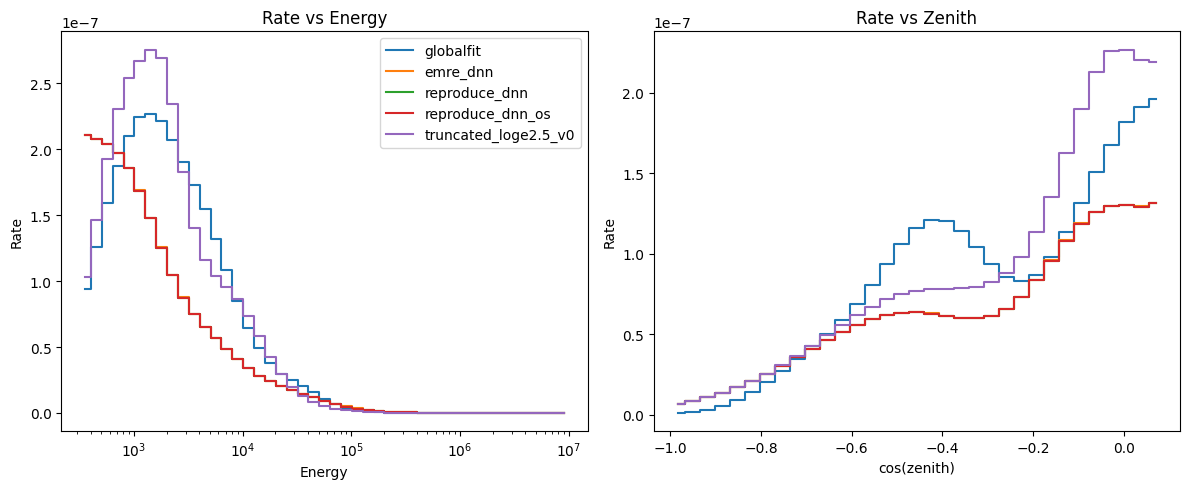

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

for name in data:

    print(10*"-","processing", name)

    tmpl = data[name]['template_2d_scipy']  # (nE, nZ)

    print("shape", tmpl.shape)
    print("sum tmpl", np.sum(tmpl))
    print("total_rate", data[name]["total_rate"])

    Ecent = data[name]['energy_bins_centers']
    Zcent = data[name]['zenith_bins_centers']  # or cos_zen_bin_centers depending on key

    # rate vs energy
    rate_E = np.sum(tmpl, axis=1)
    ax[0].step(Ecent, rate_E, where='mid', label=name)

    # rate vs zenith
    rate_Z = np.sum(tmpl, axis=0)
    ax[1].step(Zcent, rate_Z, where='mid')

ax[0].set_xscale('log')
ax[0].set_xlabel('Energy')
ax[0].set_ylabel('Rate')
ax[0].set_title('Rate vs Energy')
ax[0].legend()

ax[1].set_xlabel('cos(zenith)')
ax[1].set_ylabel('Rate')
ax[1].set_title('Rate vs Zenith')

plt.tight_layout()
plt.show()